In [1]:
!uv add statsmodels

Resolved 111 packages in 15ms
Checked 70 packages in 358ms


In [2]:
!uv tree -d 1

Resolved 111 packages in 9ms
ir v0.1.0
├── bs4 v0.0.2
├── feedparser v6.0.14
├── ipykernel v7.3.0
├── nltk v3.10.3
├── pandas v2.3.3
├── requests v2.34.2
├── selenium v4.48.0
└── statsmodels v0.15.0


# Measuring Quality of Search

In this notebook you will practice the two complementary ways an IR system's quality is measured:

1. **Human relevance judgments** — you and your groupmates will rate real search results yourselves, then quantify *how much you agree* (inter-rater agreement) and *how consistent your rankings are* (rank correlation).
2. **Offline evaluation against a gold set** — you will build a small "bucket" of known-relevant URLs for a query, retrieve results automatically, and compute standard ranking-quality metrics: **MRR@k** and **Precision@k**.

<!-- By the end of this notebook you should be able to:
- Explain the elements of a Search Engine Results Page (SERP).
- Rate documents using a standard relevance scale.
- Compute Fleiss' kappa and Kendall's tau, and interpret them.
- Compute MRR@k and Precision@k for a ranked result list. -->


# 1. Assessor and analyst work

## 1.0. Rating and criteria

Please [open this document](https://static.googleusercontent.com/media/guidelines.raterhub.com/en//searchqualityevaluatorguidelines.pdf)
and study chapters 13.0-13.4. Your task will be to assess the organic answers of search engines given the same query.

## 1.1. Explore the page

For the following search engines:
- https://duckduckgo.com/
- https://www.bing.com/
- https://ya.ru/
- https://www.google.com/

Perform the same query: "**How to get from Kazan to Voronezh**".

1. Which elements you may identify at SERP? Ads, snippets, ...?
2. Where are organic results? How many of them are there?


## 1.2. Rate the results of the search engine

If there are many of you in the group, assess all search engines, otherwise choose 1 or 2. There should be no less than 3 of you for each search engine. Use the scale from the handbook, use 0..4 numerical equivalents for `[FailsM, SM, MM, HM, FullyM]`.


**FailsM** — Fails to Meet : The result is unhelpful or irrelevant to the query; doesn't address the user's need at all.<br>
**SM** — Slightly Meets : Only marginally useful; addresses a small part of the need or is tangentially related.<br>
**MM** — Moderately Meets: Reasonably helpful but incomplete, or helpful for only some users/interpretations of the query.<br>
**HM** — Highly Meets : Very helpful and relevant; satisfies the need well, even if not perfect.<br>
**FullyM** — Fully Meets : Completely and satisfyingly answers the query — the ideal result.<br>


Compute:
- average relevance and standard deviation for each SERP element.
- [Fleiss kappa score](https://en.wikipedia.org/wiki/Fleiss%27_kappa#Worked_example) for your group. Use [this implementation](https://www.statsmodels.org/dev/generated/statsmodels.stats.inter_rater.fleiss_kappa.html).
- [Kendall rank coefficient](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient) for some pairs in your group. Use [this implementation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kendalltau.html).

Discuss numerical results. Did you agree on the relevance? Did you agree on the rank? What is the difference?

> **Note:** the cells below contain a *worked example* with empty/synthetic data for 3 assessors rating 10 results, so you can see the full pipeline run end-to-end. **Replace `ranking_data` with your own group's ratings** before you draw conclusions in your report.


In [ ]:
import numpy as np

# Rows = assessors, columns = the 10 SERP items they rated (0..4 relevance scale).
# Add your own group's ratings.
ranking_data = np.array([
    [, , , , , , , , , ],  # assessor 1 relevance
    [, , , , , , , , , ],  # assessor 2 relevance
    [, , , , , , , , , ],  # assessor 3 relevance
])

n_assessors, n_items = ranking_data.shape
print(f"{n_assessors} assessors, {n_items} items")


5 assessors, 10 items


Averages and standard deviations per item.

In [6]:
means = ranking_data.mean(axis=0)
stds = ranking_data.std(axis=0) 

for i, (m, s) in enumerate(zip(means, stds)):
    print(f"{i:2d} relevance {m:.2f} ± {s:.3f}")


 0 relevance 3.80 ± 0.400
 1 relevance 3.80 ± 0.400
 2 relevance 4.00 ± 0.000
 3 relevance 3.60 ± 0.490
 4 relevance 3.40 ± 0.490
 5 relevance 2.20 ± 0.400
 6 relevance 1.80 ± 0.400
 7 relevance 1.00 ± 0.000
 8 relevance 1.00 ± 0.000
 9 relevance 1.00 ± 1.095


## Fleiss' kappa score

Fleiss' kappa measures agreement between *several* raters on *categorical* ratings, correcting for the agreement expected by chance.
 <!-- It ranges from -1 (systematic disagreement) to 1 (perfect agreement); values around 0.4-0.6 -->
<!-- are usually considered "moderate" agreement, above 0.75 "excellent". -->

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQqsDScEKlWs4xfVXutn0ExRTKVWzOAfDE7LyGT7tejhg&s=10)

`statsmodels` expects an **agreement matrix**: one row per item, one column per category, with the count of
raters that assigned that category. `aggregate_raters` builds this matrix directly from our `ranking_data`.

In [ ]:
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa

# aggregate_raters expects rows = subjects (items), columns = raters (assessors)
agreement, categories = ??

print("Agreement matrix:")
print(agreement)
print("Categories:", categories)

kappa = fleiss_kappa(??, method='fleiss')
print("Kappa:", kappa)


Agreement matrix:
[[0 0 0 1 4]
 [0 0 0 1 4]
 [0 0 0 0 5]
 [0 0 0 2 3]
 [0 0 0 3 2]
 [0 0 4 1 0]
 [0 1 4 0 0]
 [0 5 0 0 0]
 [0 5 0 0 0]
 [2 2 0 1 0]]
Categories: [0 1 2 3 4]
Kappa: 0.5156081808396124


## Kendall's tau

Fleiss' kappa tells us whether assessors picked the *same relevance labels*; it says nothing about whether they
*ranked* the results similarly. Kendall's tau is a pairwise rank-correlation coefficient: +1 means two assessors
ranked the items identically, -1 means completely reversed, 0 means no relationship.

Kendall's tau is pairwise, so with more than two assessors we compute it for every pair.

In [ ]:
from itertools import combinations
from scipy.stats import kendalltau


for i, j in combinations(??, 2):
    tau, pvalue = ??
    print(f"assessor {i + 1} vs assessor {j + 1}: tau={tau:.3f}, p-value={pvalue:.4f}")


assessor 1 vs assessor 2: tau=0.867, p-value=0.0029
assessor 1 vs assessor 3: tau=0.687, p-value=0.0180
assessor 1 vs assessor 4: tau=0.878, p-value=0.0019
assessor 1 vs assessor 5: tau=0.843, p-value=0.0034
assessor 2 vs assessor 3: tau=0.714, p-value=0.0127
assessor 2 vs assessor 4: tau=0.920, p-value=0.0010
assessor 2 vs assessor 5: tau=0.917, p-value=0.0012
assessor 3 vs assessor 4: tau=0.595, p-value=0.0329
assessor 3 vs assessor 5: tau=0.778, p-value=0.0061
assessor 4 vs assessor 5: tau=0.790, p-value=0.0042


### Discussion

Replace the synthetic data above with your own group's ratings, re-run the cells, and discuss:

1. Did you agree on the **relevance** (Fleiss' kappa)? Which items had the most disagreement, and why do you
   think that happened (ambiguous query intent, borderline relevance, misreading the page, ...)?
2. Did you agree on the **rank** (Kendall's tau)? Is rank agreement higher or lower than label agreement — what
   does that tell you about how strict vs. lenient different assessors are?
3. Compare kappa/tau across the different search engines you evaluated (if your group split the work). Which
   engine produced results that were easiest to agree on?


# 2. Engineer work

You will create a bucket of URLs which are relevant for the query **"free cloud git"**. Then you will automate the
search procedure using https://serpapi.com/, or https://developers.google.com/custom-search/v1/overview, or whatever.

Then you will compute MRR@10 and Precision@10.

## 2.1. Build your bucket here

In [11]:
# Domains we consider a relevant answer to "free cloud git" (i.e. cloud-hosted git repository services).
# Extend this list with anything your group agrees is a legitimate, free, cloud git host.
rel_bucket = [
    "github.com",
    "gitlab.com",
    "bitbucket.org",
    "gitpod.io",
    "sourceforge.net",
    "codeberg.org",
    "gitea.com",
]

query = "free cloud git"


## 2.2. Relevance assessment

Write the code to check that the obtained document is relevant (True) or not (False).

In [ ]:
from urllib.parse import urlparse

def is_rel(resp_url: str) -> bool:
    """A result is relevant if its host is in rel_bucket, or a subdomain of one of those domains
    (e.g. 'about.gitlab.com' still counts for 'gitlab.com')."""
    # TODO


# quick sanity checks
assert is_rel("https://github.com/") is True
assert is_rel("https://www.gitpod.io/") is True
assert is_rel("https://about.gitlab.com/") is True
assert is_rel("https://git-scm.com/") is False


## 2.3. Automation

Get search results from the automation tool you use. The function below calls
[SerpApi](https://serpapi.com/) if you have an API key (recommended — sign up for a free tier and put the key in
the `SERPAPI_KEY` environment variable), and otherwise falls back to a small hard-coded example page so the
notebook still runs end-to-end for demonstration purposes.

If you use Google's [Custom Search JSON API](https://developers.google.com/custom-search/v1/overview) instead,
just swap out the body of `fetch_search_results` — keep the same `{"title": ..., "link": ...}` output shape so the
rest of the notebook keeps working unchanged.

In [ ]:
import os
import requests

# Fallback data, used only if no SERPAPI_KEY is configured, so the notebook remains runnable without an API key.
_MOCK_RESULTS = [
    {"title": "6 places to host your git repository - Opensource.com", "link": "https://opensource.com/article/18/8/github-alternatives"},
    {"title": "Bitbucket | Git solution for teams using Jira", "link": "https://bitbucket.org/product"},
    {"title": "Top GitHub Alternatives to Host Your Open Source Projects", "link": "https://itsfoss.com/github-alternatives/"},
    {"title": "Gitpod: Always ready to code.", "link": "https://www.gitpod.io/"},
    {"title": "GitLab: The One DevOps Platform", "link": "https://about.gitlab.com/"},
    {"title": "14 Git Hosting Services Compared | Tower Blog", "link": "https://www.git-tower.com/blog/git-hosting-services-compared/"},
    {"title": "Top 10 best Git hosting solutions and services in 2021", "link": "https://www.devopsschool.com/blog/top-5-git-hosting-solutions/"},
    {"title": "GitHub: Let's build from here · GitHub", "link": "https://github.com/"},
    {"title": "Git", "link": "https://git-scm.com/"},
    {"title": "Sourcetree | Free Git GUI for Mac and Windows", "link": "https://www.sourcetreeapp.com/"},
]


def fetch_search_results(query: str, num: int = 10) -> list[dict]:
    """Return a list of {"title": str, "link": str} dicts for the top `num` organic results."""
    api_key = os.environ.get("SERPAPI_KEY")
    if not api_key:
        print("[info] SERPAPI_KEY not set - using bundled example results instead of a live search.")
        return _MOCK_RESULTS[:num]

    response = ?? 
    
    #TODO
    
    response.raise_for_status()
    
    # TODO
    
    return [{"title": r.get("title", ""), "link": r.get("link", "")} for r in organic[:num]]


results = fetch_search_results(query, num=10)

for rank, r in enumerate(results, start=1):
    relevant = is_rel(r["link"])
    print(rank, r["title"])
    print(r["link"])
    print(relevant)
    print()


[info] SERPAPI_KEY not set - using bundled example results instead of a live search.
1 6 places to host your git repository - Opensource.com
https://opensource.com/article/18/8/github-alternatives
False

2 Bitbucket | Git solution for teams using Jira
https://bitbucket.org/product
True

3 Top GitHub Alternatives to Host Your Open Source Projects
https://itsfoss.com/github-alternatives/
False

4 Gitpod: Always ready to code.
https://www.gitpod.io/
True

5 GitLab: The One DevOps Platform
https://about.gitlab.com/
True

6 14 Git Hosting Services Compared | Tower Blog
https://www.git-tower.com/blog/git-hosting-services-compared/
False

7 Top 10 best Git hosting solutions and services in 2021
https://www.devopsschool.com/blog/top-5-git-hosting-solutions/
False

8 GitHub: Let's build from here · GitHub
https://github.com/
True

9 Git
https://git-scm.com/
False

10 Sourcetree | Free Git GUI for Mac and Windows
https://www.sourcetreeapp.com/
False



In [14]:
rels = [int(is_rel(r["link"])) for r in results]
rels


[0, 1, 0, 1, 1, 0, 0, 1, 0, 0]

## 2.4. MRR

**Mean Reciprocal Rank** rewards finding the *first* relevant result quickly. For a single query, the reciprocal
rank is `1 / rank_of_first_relevant_result` (0 if no relevant result appears in the top `k`). MRR averages this
over several queries.
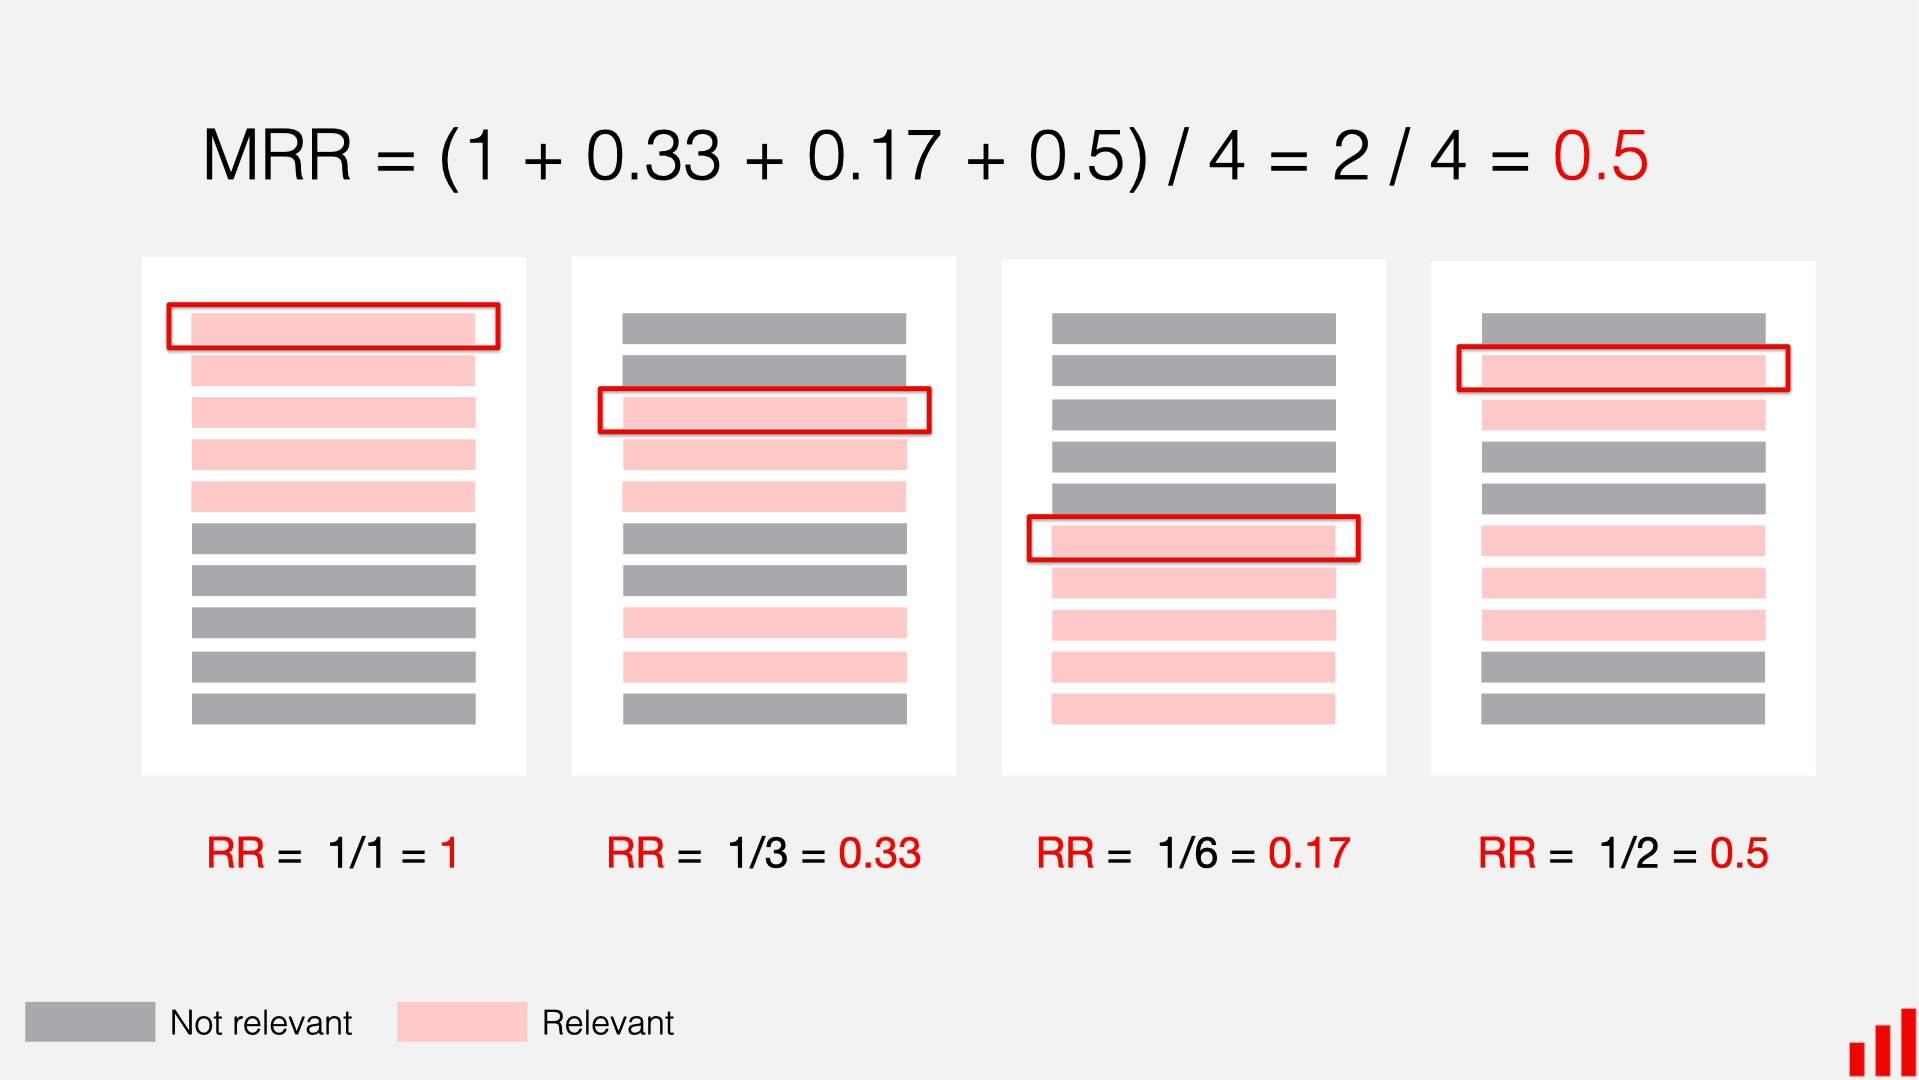

Compute MRR:

In [ ]:
def mrr(list_of_lists, k=10):
    """list_of_lists: one relevance list (0/1) per query, in ranked order."""
    reciprocal_ranks = []
    for rels_for_query in list_of_lists:
        rr = 0.0

        # TODO
        
        reciprocal_ranks.append(rr)
    return float(np.mean(reciprocal_ranks))


In [16]:
mrr([rels])  # BTW, why do I wrap the list into additional brackets? :)
# Because mrr() expects one relevance list PER QUERY. We only ran one query ("free cloud git"),
# so we wrap our single `rels` list in an outer list of length 1. With more queries you would pass
# e.g. mrr([rels_query1, rels_query2, ...]).


0.5

## 2.5. Precision
Compute mean precision:

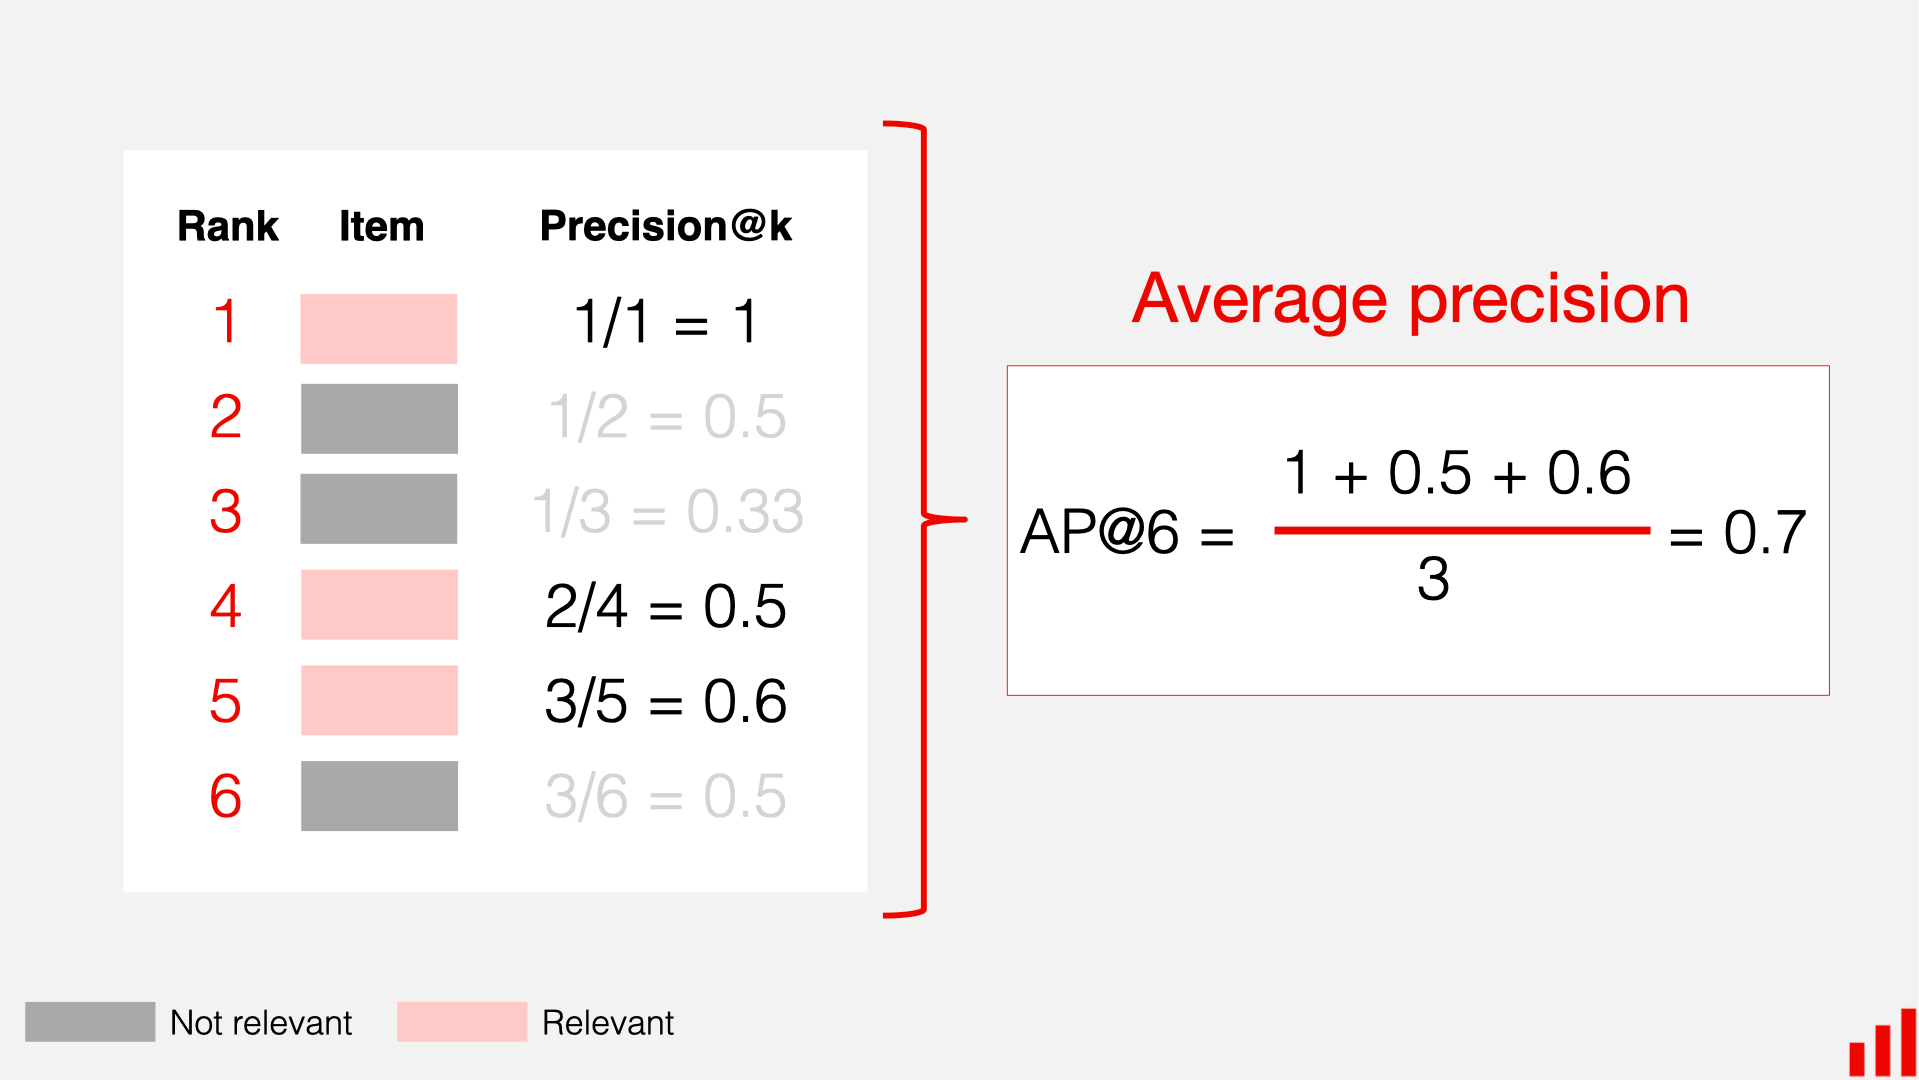

In [ ]:
def mp(list_of_lists, k=10):
    """Mean Precision@k across queries: for each query, the fraction of the top-k results that are relevant."""
    # TODO
    precisions = ??
    return float(np.mean(precisions))


In [18]:
mp([rels])


0.4

# 2.6. CG
Cumulative gain is a measure of the total relevance of the ranked list. It sums up the relevance scores of the individual items in the list. A gain of a single recommended item is its relevance score, be it binary or graded. The cumulative gain is a sum of scores of all relevant items among the top-K results in the list.

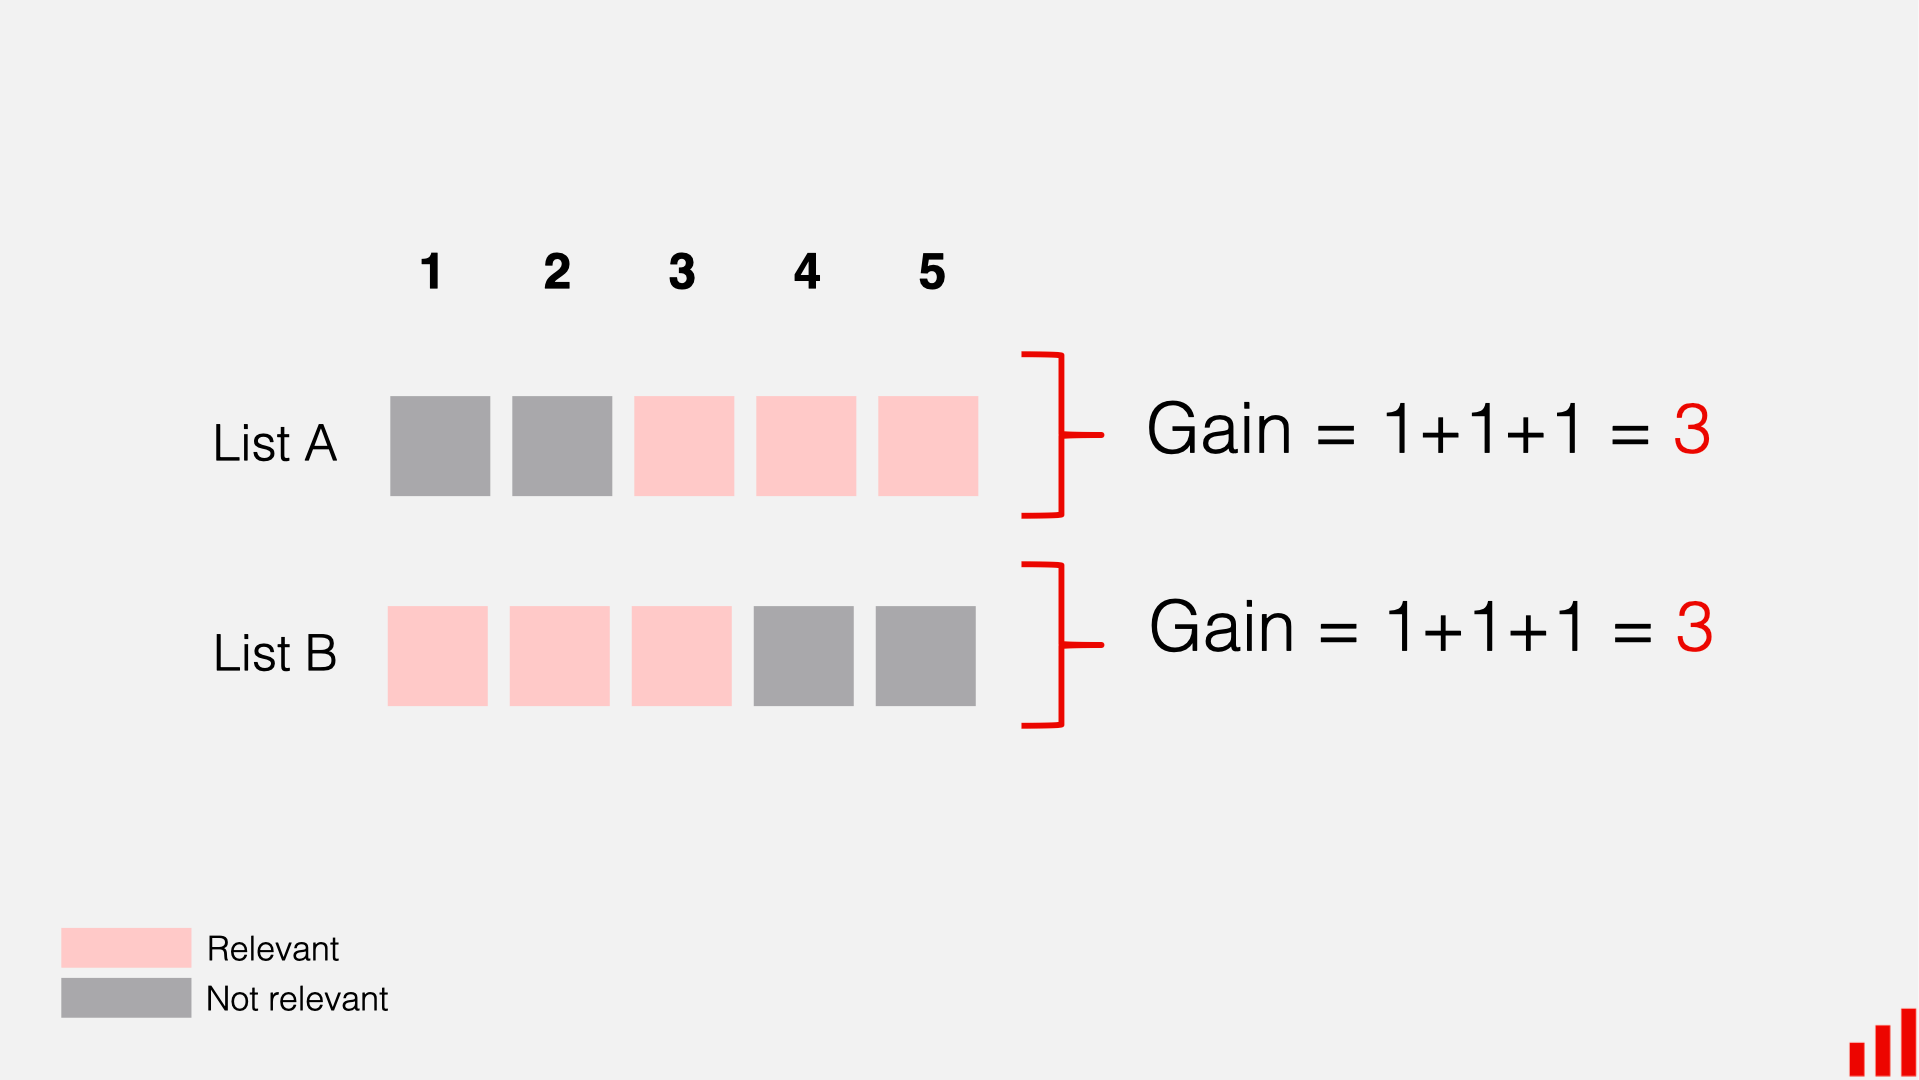

# 2.8. DCG

A logarithmic discount helps assign lower gain when relevant items appear further down in the ranked list.

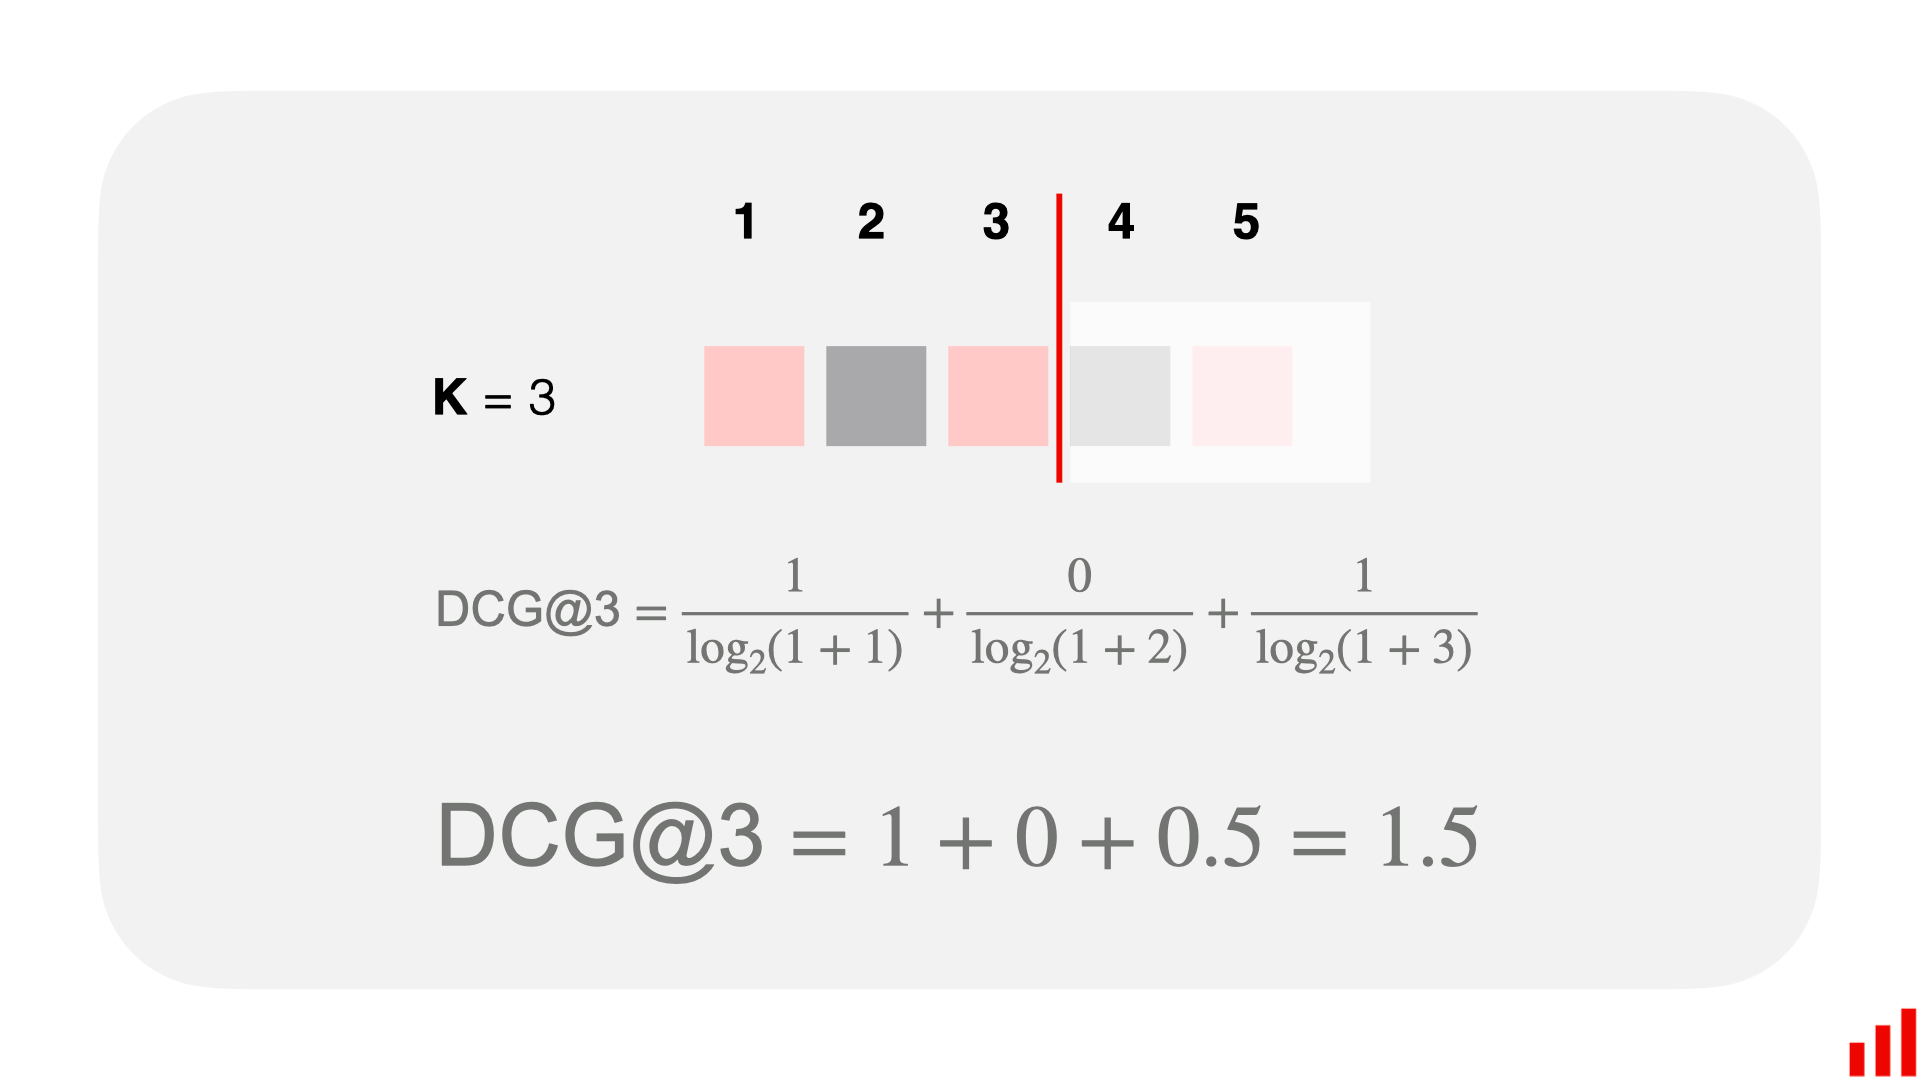

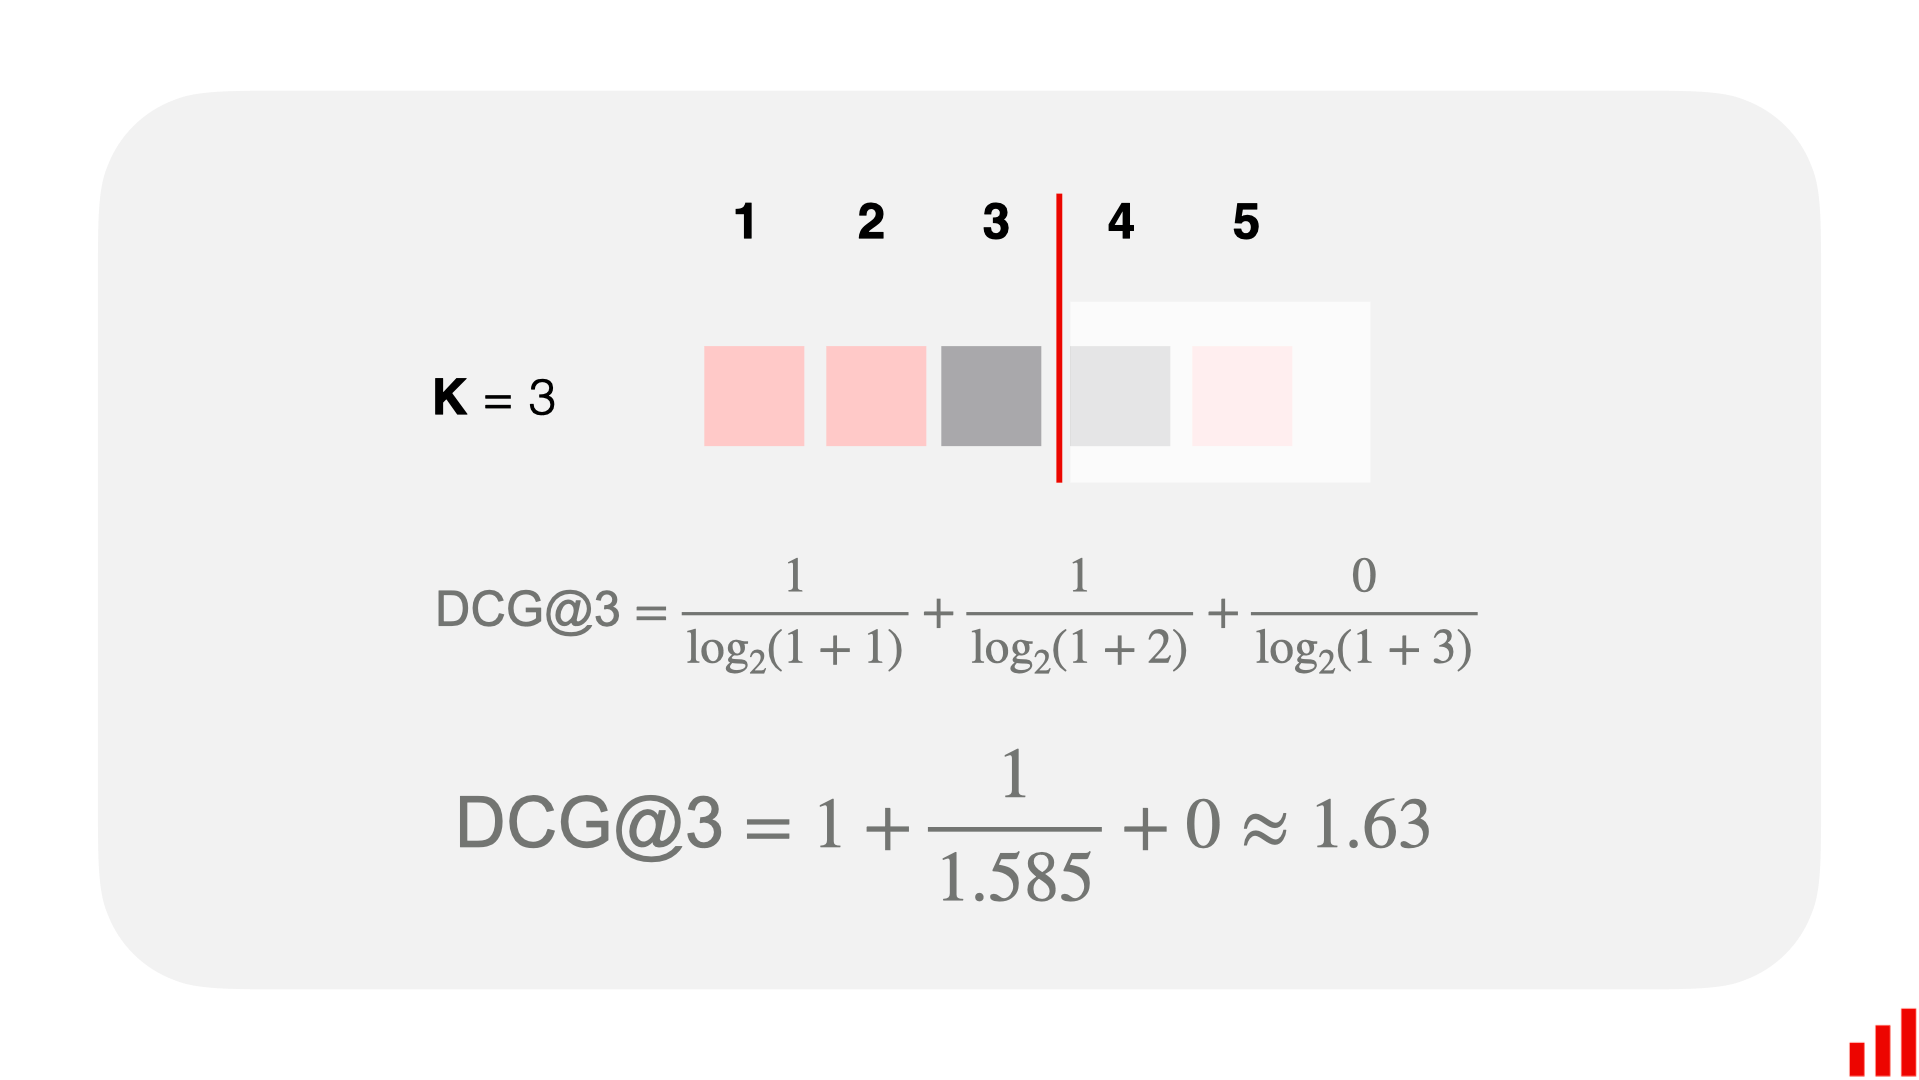

**Limitation:** Longer lists have higher potential DCG values since more items can contribute to the score. DCG at 10 can be higher than DCG at 3 simply due to the length of the list rather than the inherently better ranking. Using binary or graded relevance will also lead to different gain values.

## 2.9. nDCG@10

MRR only cares about the *first* relevant result, and Precision@k treats every relevant result as equally good regardless of position. Other gain-based metrics also do not provide normalzied scores. **Normalized Discounted Cumulative Gain (nDCG)** rewards relevant results more the higher they are ranked, and works with graded (not just binary) relevance — try plugging in your 0-4 relevance scores from Part 1 instead of 0/1 values. To normalize DCG, you can divide it by the ideal ranking (IDCG@k), where every item appears in the order of relevance. 

IDCG represents the maximum achievable DCG with the same set of relevance scores but in the perfect ranking order. 

- NDCG can take values from 0 to 1. 
- NDCG equals 1 in the case of ideal ranking when items are perfectly sorted by relevance. 
- NDCG equals 0 when there are no relevant objects in top-K.
- NDCG can be between 0 and 1 in all other cases. The higher the NDCG, the better. 

In [ ]:
def dcg(relevances, k=10):
    # TODO


def ndcg(relevances, k=10):
    # TODO


ndcg(rels, k=10)


0.6886007376100177

## Wrap-up

You have now exercised both sides of measuring search quality:

- **Human evaluation** — relevance rating, Fleiss' kappa (agreement on *labels*), Kendall's tau (agreement on
  *rank*).
- **Automatic offline evaluation** — a relevance bucket used as ground truth, with MRR@k, Precision@k, and
  (bonus) nDCG@k computed against it.

<!-- For your submission, replace every example dataset above with your own group's data and results, and answer the discussion questions inline. -->